In [ ]:
# 📦 STEP 1: Install required packages (if needed)
!pip install statsforecast pandas matplotlib scipy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 9.0 MB/s eta 0:00:00


In [ ]:
# 📌 STEP 2: Load and filter uploaded data
import pandas as pd

# Load train.csv
df = pd.read_csv("train.csv")

# Filter one store and one item for forecasting (e.g., store 1, item 1)
df = df[(df['store'] == 1) & (df['item'] == 1)]

# Format date and rename columns
df['date'] = pd.to_datetime(df['date'])
df = df.rename(columns={'date': 'ds', 'sales': 'y'})
df = df[['ds', 'y']].sort_values('ds').reset_index(drop=True)

# Preview
df.head()

,ds,y
0,2013-01-01,13
1,2013-01-02,11
2,2013-01-03,14
3,2013-01-04,13
4,2013-01-05,10


In [ ]:
# 📌 STEP 3: Split into training and testing sets
# Use 80% for training, 20% for testing
split_point = int(len(df) * 0.8)
train_df = df[:split_point]
test_df = df[split_point:]

print("Training set:", train_df.shape)
print("Testing set:", test_df.shape)

Training set: (1460, 2)
Testing set: (366, 2)


In [ ]:
# 📌 STEP 4: Add unique_id column and forecast with StatsForecast
train_df['unique_id'] = 'item_1_store_1'
test_df['unique_id'] = 'item_1_store_1'

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

sf = StatsForecast(models=[AutoARIMA(season_length=7)], freq='D')
sf.fit(train_df)

# Forecast for same length as test set
horizon = len(test_df)
forecast_df = sf.predict(h=horizon, level=[95])

<ipython-input-4-15d2a9c2b5d6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['unique_id'] = 'item_1_store_1'
<ipython-input-4-15d2a9c2b5d6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['unique_id'] = 'item_1_store_1'


In [ ]:
# 📌 STEP 5: Calculate Safety Stock from training error
from scipy.stats import norm
import numpy as np

# Define forecast horizon (e.g., 7 days) and specify the DataFrame
horizon = 7

# Run the forecast with fitted values enabled; ensure you pass 'h' and 'df'
forecast_results = sf.forecast(h=horizon, df=train_df, fitted=True)

# Now get the fitted values from the forecast
fitted_df = sf.forecast_fitted_values()
train_df['fitted'] = fitted_df['AutoARIMA'].values

# Calculate residuals on training data
train_df['error'] = train_df['y'] - train_df['fitted']

# Calculate the standard deviation of these residuals
sigma = train_df['error'].std()

# Calculate the 95% service level z-score and define lead time
Z = norm.ppf(0.95)  # 95% service level
lead_time = 7       # 7-day lead time

# Calculate the safety stock
safety_stock = Z * sigma * np.sqrt(lead_time)

print(f"✅ Safety Stock (95% service level, 7-day lead time): {safety_stock:.2f} units")

✅ Safety Stock (95% service level, 7-day lead time): 21.88 units


<ipython-input-5-c38c0815b37f>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['fitted'] = fitted_df['AutoARIMA'].values
<ipython-input-5-c38c0815b37f>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['error'] = train_df['y'] - train_df['fitted']


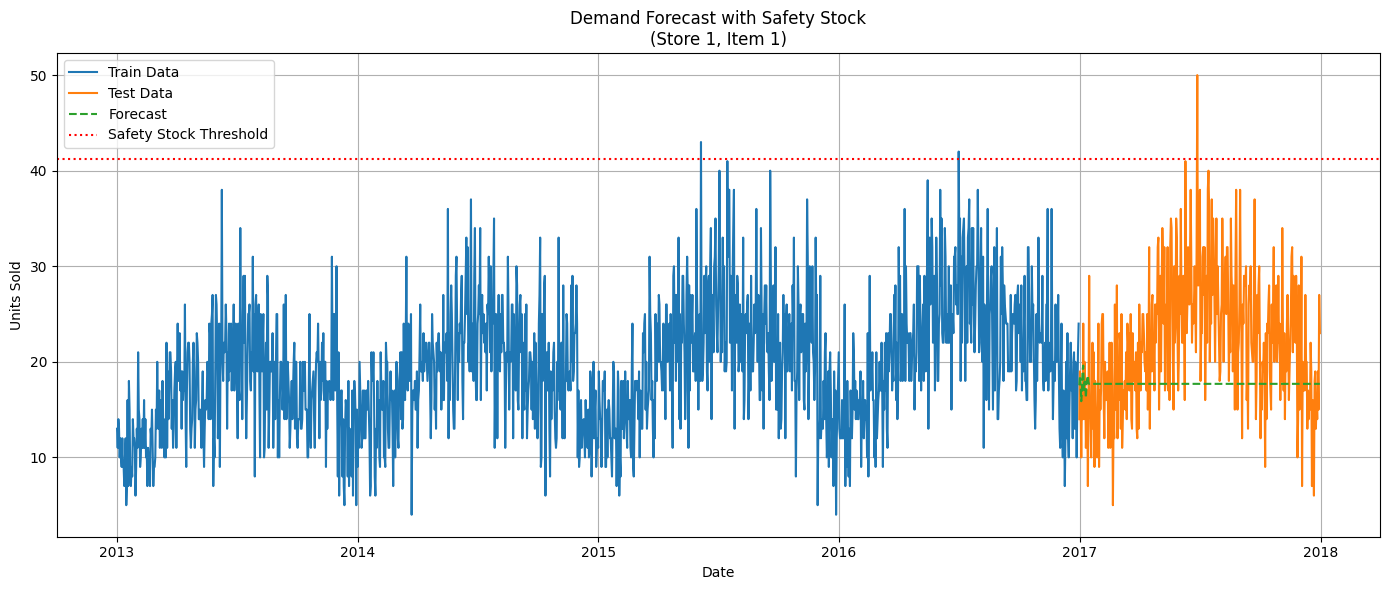

In [ ]:
# 📌 STEP 6: Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(train_df['ds'], train_df['y'], label='Train Data')
plt.plot(test_df['ds'], test_df['y'], label='Test Data')
plt.plot(forecast_df['ds'], forecast_df['AutoARIMA'], label='Forecast', linestyle='--')
plt.axhline(y=train_df['fitted'].mean() + safety_stock, color='red', linestyle=':', label='Safety Stock Threshold')
plt.title('Demand Forecast with Safety Stock\n(Store 1, Item 1)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()